# 302a — Probability-weighted individual parameter uncertainty for depletion_q designs

This notebook evaluates probability-weighted uncertainty for **one parameter at a time** while holding the validated baseline `depletion_q` Pareto pumping designs fixed.

Currently supported parameters:

- `transmissivity` using `project_properties.T`
- `storage` using `project_properties.S`

The main question is:

> If a pumping plan was optimized using the baseline parameter value, what is the expected hydrologic cost when that parameter is uncertain?


## 1. Imports, helper reload, and user controls

To run storage, set:

```python
PARAMETER_TO_RUN = "storage"
```

To rerun transmissivity, set:

```python
PARAMETER_TO_RUN = "transmissivity"
```

Recommended workflow:

1. Run a small test with `N_TEST_MEMBERS = 10`.
2. Run the full front with `N_TEST_MEMBERS = None` and `RERUN_REEVALUATION = True`.
3. After the full cache exists, switch to `RERUN_REEVALUATION = False`.


In [37]:
from pathlib import Path
import sys
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

sys.modules.pop("uncertainty_project_helpers_depletion_q", None)
importlib.invalidate_caches()
import uncertainty_project_helpers_depletion_q as up

print("Helper imported from:", up.__file__)
print("Helper version:", up.HELPER_VERSION)

PROJECT_DIR = up.find_lpr_pycap_opt_dir()
NOTEBOOK_DIR = PROJECT_DIR / "notebooks" / "Uncertainty_Project_depletion_q"
PROJECT_OUTPUT_DIR = NOTEBOOK_DIR / "project_output"
CACHE_DIR = NOTEBOOK_DIR / "cached_reevaluations"

RUN_NAME = "depletion_q_baseline_0.0_1.0_0.01"

# Supported: "transmissivity" or "storage".
PARAMETER_TO_RUN = "transmissivity"
PARAMETER_CONFIG = up.get_parameter_config(PARAMETER_TO_RUN)
PARAMETER_OUTPUT_TAG = PARAMETER_CONFIG["scenario_tag"]
PARAMETER_LABEL = PARAMETER_CONFIG["label"]
PARAMETER_SYMBOL = PARAMETER_CONFIG["symbol"]

# Probability model settings. With sigma_fraction=0.10 and n_sigma_each_side=2,
# the parameter-factor range is 0.8 to 1.2.
PARAMETER_SIGMA_FRACTION = 0.10
N_SIGMA_EACH_SIDE = 2.0
N_PARAMETER_VALUES = 11

RERUN_REEVALUATION = False
N_TEST_MEMBERS = None

OUTPUT_DIR = PROJECT_OUTPUT_DIR / "302a_probability_weighted_individual_parameter_uncertainty_depletion_q" / PARAMETER_OUTPUT_TAG
CACHE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CACHE_FILE = CACHE_DIR / f"302a_depletion_q_{PARAMETER_OUTPUT_TAG}_probability_reevaluation_v1.csv"
ERROR_CACHE_FILE = CACHE_DIR / f"302a_depletion_q_{PARAMETER_OUTPUT_TAG}_probability_reevaluation_errors_v1.csv"

up.apply_plot_style()

print("PROJECT_DIR:", PROJECT_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("CACHE_FILE:", CACHE_FILE)
print("PARAMETER_TO_RUN:", PARAMETER_TO_RUN)
print("PARAMETER_SIGMA_FRACTION:", PARAMETER_SIGMA_FRACTION)
print("N_SIGMA_EACH_SIDE:", N_SIGMA_EACH_SIDE)
print("N_PARAMETER_VALUES:", N_PARAMETER_VALUES)
print("RERUN_REEVALUATION:", RERUN_REEVALUATION)
print("N_TEST_MEMBERS:", N_TEST_MEMBERS)


Helper imported from: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/uncertainty_project_helpers_depletion_q.py
Helper version: 2026-05-24_depletion_q_304_v7_full_uncertainty_annotation_higher
PROJECT_DIR: /workspaces/LPR_redux/LPR_pycap_opt
OUTPUT_DIR: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/302a_probability_weighted_individual_parameter_uncertainty_depletion_q/transmissivity
CACHE_FILE: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/cached_reevaluations/302a_depletion_q_transmissivity_probability_reevaluation_v1.csv
PARAMETER_TO_RUN: transmissivity
PARAMETER_SIGMA_FRACTION: 0.1
N_SIGMA_EACH_SIDE: 2.0
N_PARAMETER_VALUES: 11
RERUN_REEVALUATION: False
N_TEST_MEMBERS: None


## 2. Load the depletion_q baseline context and Pareto designs

The design population comes from the baseline `depletion_q` Pareto archive. The pumping plan is held fixed while the selected parameter is perturbed across the probability distribution.


In [38]:
context = up.load_depletion_q_context(RUN_NAME, project_dir=PROJECT_DIR)
archive = up.read_pareto_archive_summary(RUN_NAME, context.run_dir)
pareto_final = up.select_final_feasible_front1(archive)
dv_df = up.load_decision_variable_population(context.run_dir)

if N_TEST_MEMBERS is not None:
    pareto_final = pareto_final.head(int(N_TEST_MEMBERS)).copy()

all_q_cols = up.get_q_columns(dv_df)
base_parameter_value = up.get_project_parameter_value(context.initial_dict_master, PARAMETER_TO_RUN)

print("Run directory:", context.run_dir)
print("Base T:", up.get_project_parameter_value(context.initial_dict_master, "transmissivity"))
print("Base S:", up.get_project_parameter_value(context.initial_dict_master, "storage"))
print("Parameter being tested:", PARAMETER_LABEL)
print("Base parameter value:", base_parameter_value)
print("Number of final front members selected:", len(pareto_final))
print("Decision-variable population shape:", dv_df.shape)
print("Number of all pumping columns in dv_df:", len(all_q_cols))
print("Number of decision-variable pumping columns from PEST control file:", len(context.decvar_q_cols))

display(pareto_final[["member", "generation", "obj_well", up.DEPLETION_OBS_NAME]].head())


Run directory: /workspaces/LPR_redux/LPR_pycap_opt/pycap_runs/pycap_pest/run_depletion_q_baseline_0.0_1.0_0.01
Base T: 1700.0
Base S: 0.12
Parameter being tested: Transmissivity
Base parameter value: 1700.0
Number of final front members selected: 296
Decision-variable population shape: (8772, 327)
Number of all pumping columns in dv_df: 327
Number of decision-variable pumping columns from PEST control file: 86


,member,generation,obj_well,lpr:total_combined:bdpl
8495,152,50,17542.80,4.782580
8496,gen=36_member=6021_pso,50,7060.34,0.811083
8497,16,50,17265.50,4.489270
8498,130,50,17325.00,4.690710
8499,95,50,17459.90,4.701270


## 3. Build the probability model

This creates a discrete normal probability distribution centered on the baseline parameter value.

For the current settings:

```text
factor range = 0.8 to 1.2
sigma = 10% of the baseline value
number of parameter values = 11
```


In [39]:
probability_table = up.make_normal_project_parameter_probability_table(
    parameter_name=PARAMETER_TO_RUN,
    base_value=base_parameter_value,
    sigma_fraction=PARAMETER_SIGMA_FRACTION,
    n_sigma_each_side=N_SIGMA_EACH_SIDE,
    n_values=N_PARAMETER_VALUES,
)

weights_path = OUTPUT_DIR / f"302a_{PARAMETER_OUTPUT_TAG}_probability_weights.csv"
probability_table.to_csv(weights_path, index=False)

print("Saved probability weights:", weights_path)
display(probability_table)
print("Sum of probability weights:", probability_table["probability_weight"].sum())


Saved probability weights: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/302a_probability_weighted_individual_parameter_uncertainty_depletion_q/transmissivity/302a_transmissivity_probability_weights.csv


,parameter_name,parameter_label,parameter_symbol,scenario,z_score,parameter_factor,parameter_value,base_parameter_value,probability_weight
0,transmissivity,Transmissivity,T,transmissivity_zminus_2p00,-2.0,0.80,1360.0,1700.0,0.022191
1,transmissivity,Transmissivity,T,transmissivity_zminus_1p60,-1.6,0.84,1428.0,1700.0,0.045589
2,transmissivity,Transmissivity,T,transmissivity_zminus_1p20,-1.2,0.88,1496.0,1700.0,0.079811
3,transmissivity,Transmissivity,T,transmissivity_zminus_0p80,-0.8,0.92,1564.0,1700.0,0.119065
4,transmissivity,Transmissivity,T,transmissivity_zminus_0p40,-0.4,0.96,1632.0,1700.0,0.151361
5,transmissivity,Transmissivity,T,baseline_transmissivity,0.0,1.00,1700.0,1700.0,0.163967
6,transmissivity,Transmissivity,T,transmissivity_zplus_0p40,0.4,1.04,1768.0,1700.0,0.151361
7,transmissivity,Transmissivity,T,transmissivity_zplus_0p80,0.8,1.08,1836.0,1700.0,0.119065
8,transmissivity,Transmissivity,T,transmissivity_zplus_1p20,1.2,1.12,1904.0,1700.0,0.079811
9,transmissivity,Transmissivity,T,transmissivity_zplus_1p60,1.6,1.16,1972.0,1700.0,0.045589


Sum of probability weights: 1.0


## 4. Re-evaluate the fixed baseline designs across the probability model

This is the computationally expensive step.

For the full run, the number of evaluations is:

```text
number of Pareto members × number of parameter values
```


In [40]:
scenarios = up.probability_table_to_project_parameter_scenarios(probability_table)
expected_rows = len(pareto_final) * len(scenarios)

print("Number of scenarios:", len(scenarios))
print("Expected rows:", expected_rows)

if RERUN_REEVALUATION or not CACHE_FILE.exists():
    results_long, error_df = up.reevaluate_depletion_q_designs(
        pareto_final=pareto_final,
        dv_df=dv_df,
        q_cols=all_q_cols,
        context=context,
        scenarios=scenarios,
        progress_every=100,
    )
    results_long.to_csv(CACHE_FILE, index=False)
    up.write_error_cache(error_df, ERROR_CACHE_FILE)
else:
    results_long = pd.read_csv(CACHE_FILE)
    error_df = up.read_csv_if_not_empty(ERROR_CACHE_FILE)

if len(results_long) != expected_rows:
    raise ValueError(f"Cached or generated result has {len(results_long)} rows, but {expected_rows} rows were expected. Set RERUN_REEVALUATION = True to rebuild the cache for the current N_TEST_MEMBERS setting.")

print("Re-evaluation rows:", len(results_long))
print("Error rows:", len(error_df))
if not error_df.empty:
    display(error_df.head())

display(results_long.head())


Number of scenarios: 11
Expected rows: 3256
Re-evaluation rows: 3256
Error rows: 0


,member,generation,scenario,parameter_name,parameter_label,parameter_symbol,parameter_factor,parameter_value,base_parameter_value,probability_weight,T_factor,T_value,S_factor,S_value,archive_pumping_objective_cfs,pumping_objective_reeval_cfs,full_model_total_pumping_cfs,archive_depletion_cfs,depletion_cfs,streamflow_cfs
0,152,50,transmissivity_zminus_2p00,transmissivity,Transmissivity,T,0.8,1360.0,1700.0,0.022191,0.8,1360.0,NaN,NaN,39.085358,39.085441,117.697971,4.782580,4.253020,4.346980
1,gen=36_member=6021_pso,50,transmissivity_zminus_2p00,transmissivity,Transmissivity,T,0.8,1360.0,1700.0,0.022191,0.8,1360.0,NaN,NaN,15.730438,15.730429,94.342958,0.811083,0.659598,7.940402
2,16,50,transmissivity_zminus_2p00,transmissivity,Transmissivity,T,0.8,1360.0,1700.0,0.022191,0.8,1360.0,NaN,NaN,38.467534,38.467529,117.080058,4.489270,3.979565,4.620435
3,130,50,transmissivity_zminus_2p00,transmissivity,Transmissivity,T,0.8,1360.0,1700.0,0.022191,0.8,1360.0,NaN,NaN,38.600100,38.600146,117.212675,4.690710,4.169856,4.430144
4,95,50,transmissivity_zminus_2p00,transmissivity,Transmissivity,T,0.8,1360.0,1700.0,0.022191,0.8,1360.0,NaN,NaN,38.900657,38.900681,117.513211,4.701270,4.174426,4.425574


## 5. Calculate probability-weighted uncertainty metrics

The main metrics are:

- expected streamflow
- streamflow standard deviation
- weighted 5th and 95th percentile streamflow
- probability-weighted absolute streamflow error
- probability-weighted streamflow shortfall

The shortfall metric is one-sided; it only counts cases where uncertain-parameter streamflow is lower than the baseline-parameter prediction.


In [41]:
results_long = up.add_probability_table_metadata(results_long, probability_table)
print("Probability metadata columns present:", [c for c in ["parameter_factor", "parameter_value", "probability_weight"] if c in results_long.columns])
print("Metadata columns with suffixes:", [c for c in results_long.columns if c.endswith("_x") or c.endswith("_y")])

member_summary = up.summarize_probability_weighted_depletion_q(results_long)
overall_summary = up.summarize_probability_weighted_overall(member_summary)
overall_summary.insert(0, "parameter_name", PARAMETER_TO_RUN)
overall_summary.insert(1, "parameter_label", PARAMETER_LABEL)

long_path = OUTPUT_DIR / f"302a_{PARAMETER_OUTPUT_TAG}_probability_reevaluation_long.csv"
member_path = OUTPUT_DIR / f"302a_{PARAMETER_OUTPUT_TAG}_probability_weighted_member_summary.csv"
overall_path = OUTPUT_DIR / f"302a_{PARAMETER_OUTPUT_TAG}_probability_weighted_overall_summary.csv"

results_long.to_csv(long_path, index=False)
member_summary.to_csv(member_path, index=False)
overall_summary.to_csv(overall_path, index=False)

print("Saved long table:", long_path)
print("Saved member summary:", member_path)
print("Saved overall summary:", overall_path)

display(member_summary.head())
display(overall_summary)


Probability metadata columns present: ['parameter_factor', 'parameter_value', 'probability_weight']
Metadata columns with suffixes: []


Saved long table: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/302a_probability_weighted_individual_parameter_uncertainty_depletion_q/transmissivity/302a_transmissivity_probability_reevaluation_long.csv
Saved member summary: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/302a_probability_weighted_individual_parameter_uncertainty_depletion_q/transmissivity/302a_transmissivity_probability_weighted_member_summary.csv
Saved overall summary: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/302a_probability_weighted_individual_parameter_uncertainty_depletion_q/transmissivity/302a_transmissivity_probability_weighted_overall_summary.csv


,member,pumping_objective_reeval_cfs,baseline_streamflow_cfs,baseline_depletion_cfs,expected_streamflow_cfs,expected_depletion_cfs,expected_streamflow_bias_from_baseline_cfs,expected_depletion_bias_from_baseline_cfs,probability_weighted_absolute_streamflow_error_cfs,probability_weighted_absolute_depletion_error_cfs,probability_weighted_streamflow_shortfall_cfs,probability_weighted_depletion_excess_cfs,streamflow_std_cfs,depletion_std_cfs,streamflow_p05_cfs,streamflow_p50_cfs,streamflow_p95_cfs,depletion_p05_cfs,depletion_p50_cfs,depletion_p95_cfs
0,152,39.085441,3.817418,4.782582,3.825280,4.774720,0.007863,-0.007863,0.180805,0.180805,0.086471,0.086471,0.225241,0.225241,3.414862,3.769368,4.167450,4.321947,4.732900,5.097670
1,gen=36_member=6021_pso,15.730429,7.788917,0.811083,7.790116,0.809884,0.001199,-0.001199,0.053741,0.053741,0.026271,0.026271,0.066850,0.066850,7.665405,7.774467,7.890374,0.678666,0.796406,0.907192
2,16,38.467529,4.110726,4.489274,4.118108,4.481892,0.007382,-0.007382,0.174415,0.174415,0.083517,0.083517,0.217262,0.217262,3.721681,4.064366,4.447912,4.045777,4.441348,4.793701
3,130,38.600146,3.909289,4.690711,3.916913,4.683087,0.007623,-0.007623,0.178071,0.178071,0.085224,0.085224,0.221806,0.221806,3.512500,3.861904,4.253716,4.237521,4.641758,5.001312
4,95,38.900681,3.898732,4.701268,3.906329,4.693671,0.007598,-0.007598,0.180247,0.180247,0.086325,0.086325,0.224513,0.224513,3.496811,3.850697,4.247152,4.242826,4.651791,5.015889


,parameter_name,parameter_label,metric,value
0,transmissivity,Transmissivity,n_members,296.000000
1,transmissivity,Transmissivity,mean_probability_weighted_absolute_streamflow_error_cfs,0.126483
2,transmissivity,Transmissivity,max_probability_weighted_absolute_streamflow_error_cfs,0.180805
3,transmissivity,Transmissivity,mean_probability_weighted_streamflow_shortfall_cfs,0.061058
4,transmissivity,Transmissivity,max_probability_weighted_streamflow_shortfall_cfs,0.086471
5,transmissivity,Transmissivity,mean_streamflow_std_cfs,0.157468
6,transmissivity,Transmissivity,max_streamflow_std_cfs,0.225241
7,transmissivity,Transmissivity,mean_expected_streamflow_bias_from_baseline_cfs,0.004368
8,transmissivity,Transmissivity,mean_probability_weighted_absolute_depletion_error_cfs,0.126483
9,transmissivity,Transmissivity,mean_probability_weighted_depletion_excess_cfs,0.061058


## 6. Create probability-weighted uncertainty figures

These plots show the parameter probability model and the streamflow uncertainty/cost metrics along the pumping front.


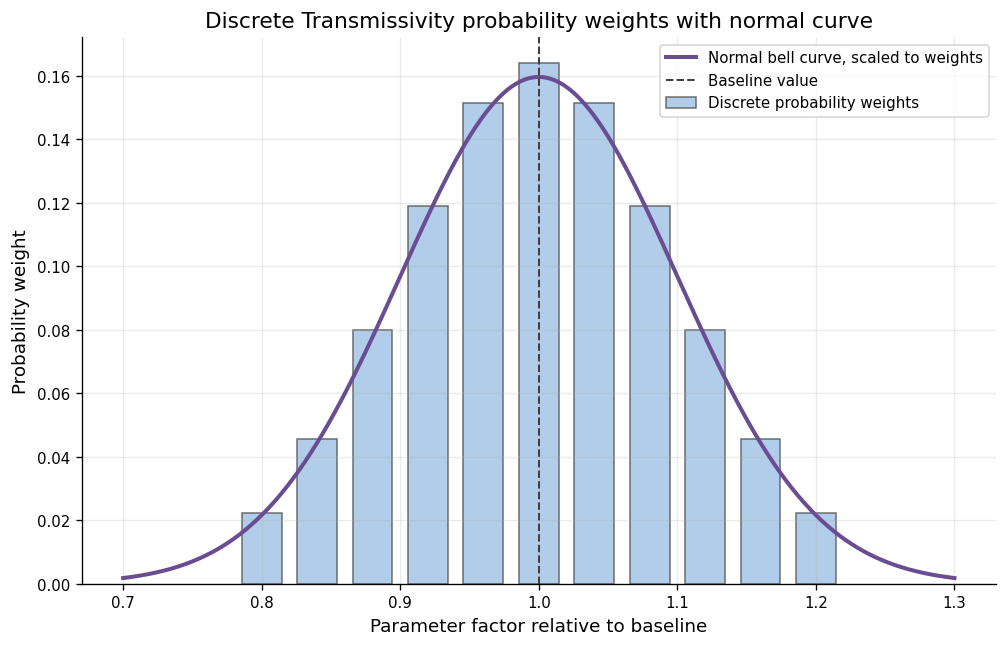

Saved figure: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/302a_probability_weighted_individual_parameter_uncertainty_depletion_q/transmissivity/302a_transmissivity_probability_weights_with_bell_curve.png


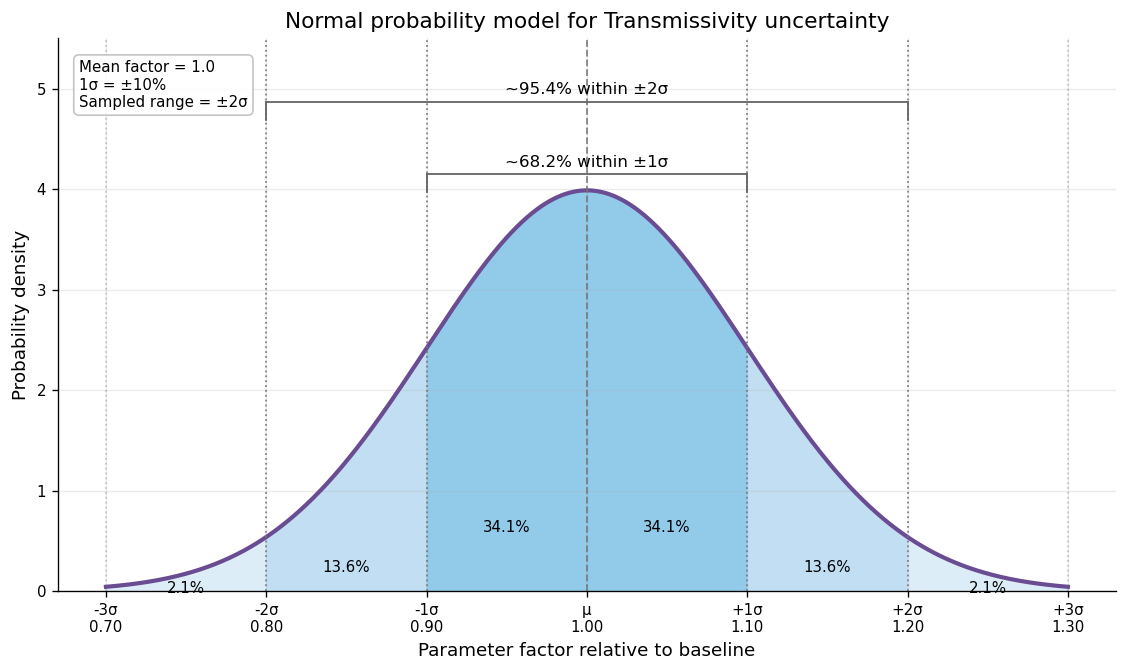

Saved figure: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/302a_probability_weighted_individual_parameter_uncertainty_depletion_q/transmissivity/302a_transmissivity_probability_shaded_sigma_regions.png


/workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/uncertainty_project_helpers_depletion_q.py:645: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


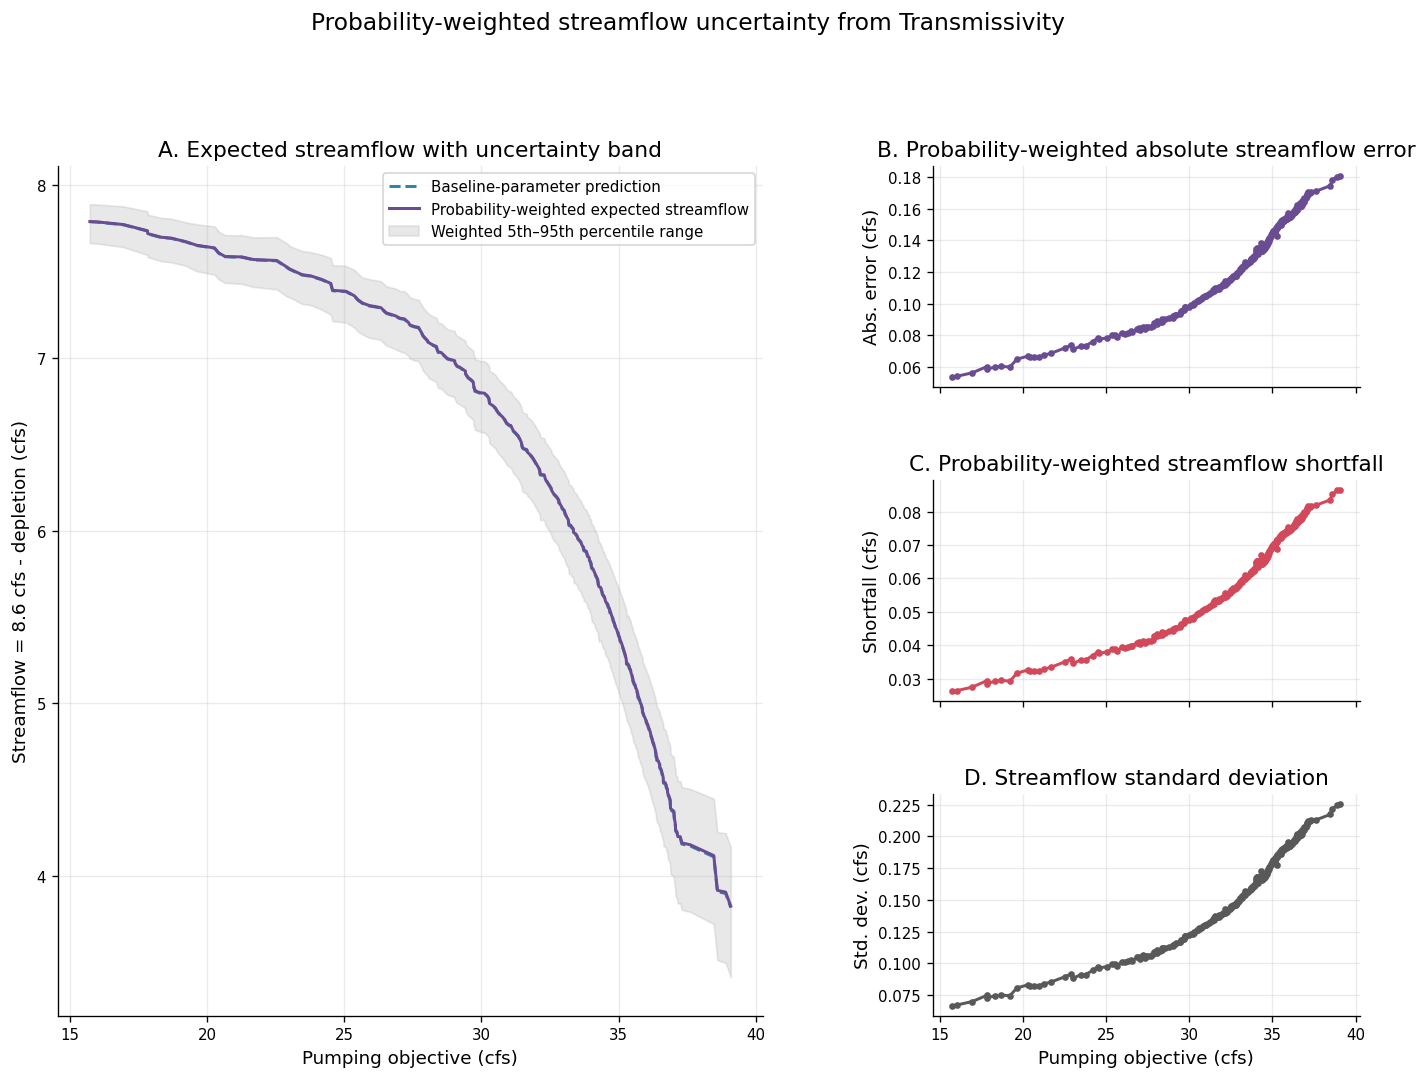

Saved figure: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/302a_probability_weighted_individual_parameter_uncertainty_depletion_q/transmissivity/302a_transmissivity_streamflow_uncertainty_dashboard.png


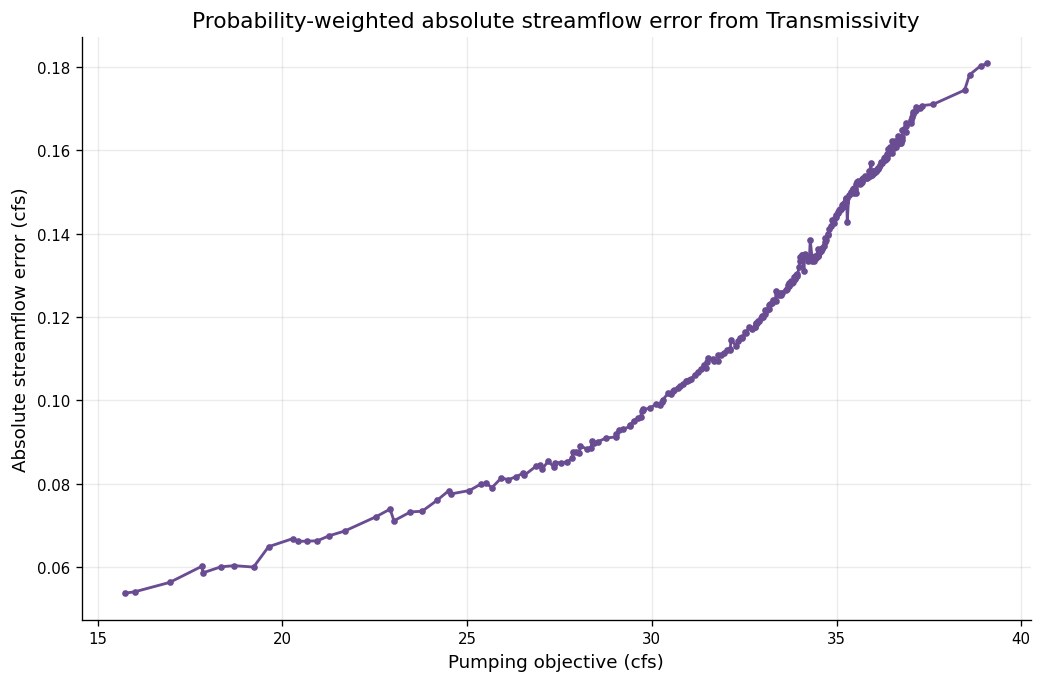

Saved figure: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/302a_probability_weighted_individual_parameter_uncertainty_depletion_q/transmissivity/302a_transmissivity_probability_weighted_absolute_streamflow_error.png


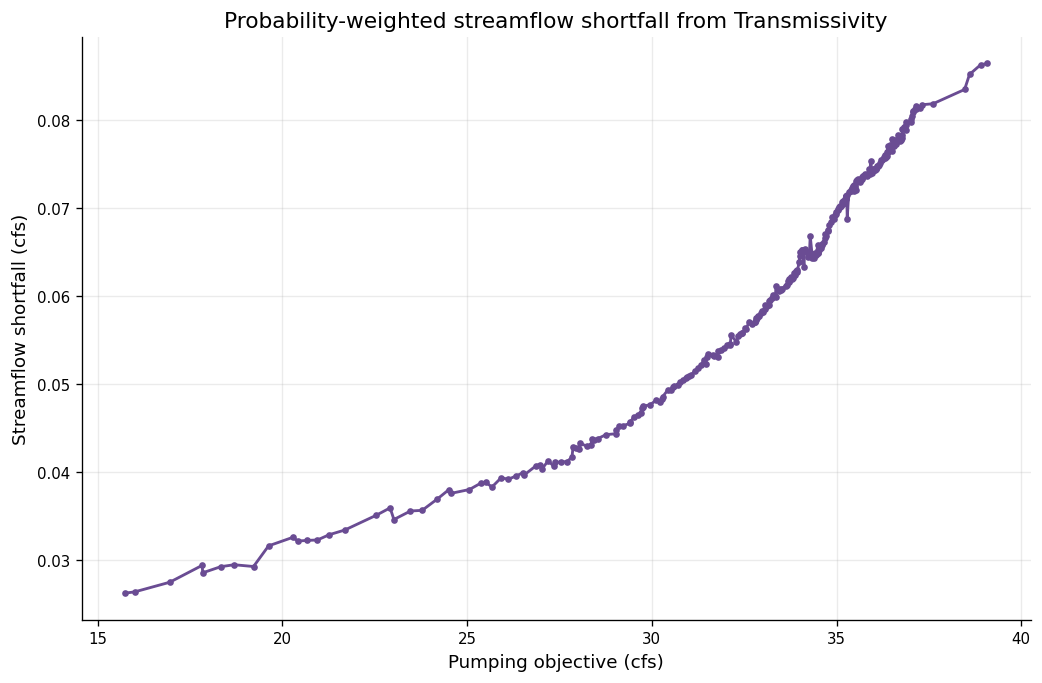

Saved figure: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/302a_probability_weighted_individual_parameter_uncertainty_depletion_q/transmissivity/302a_transmissivity_probability_weighted_streamflow_shortfall.png


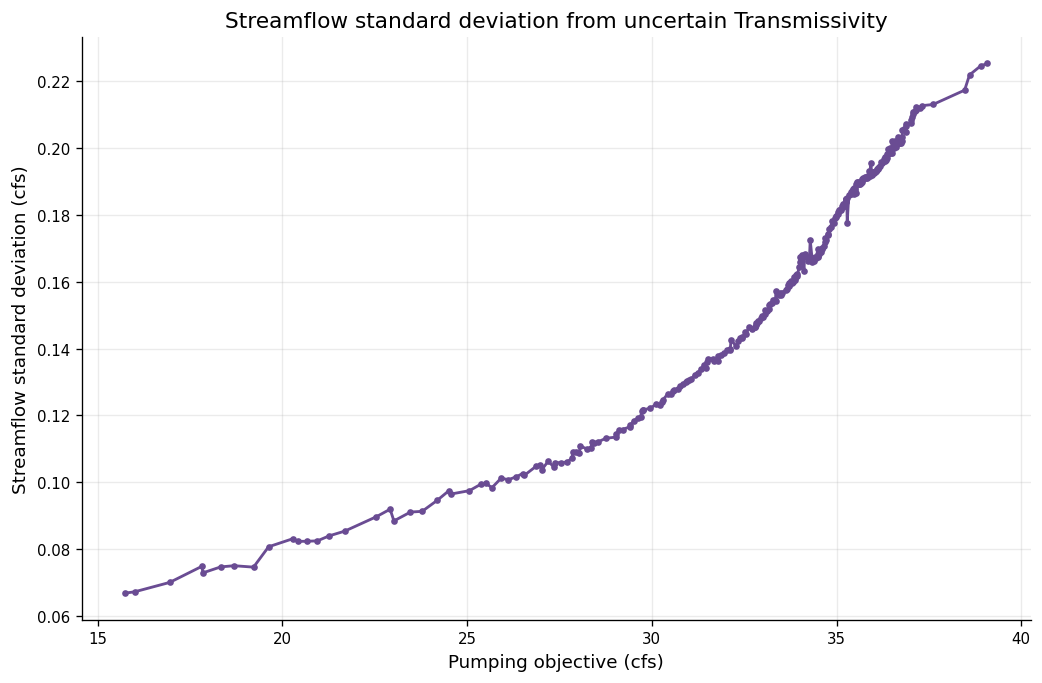

Saved figure: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/302a_probability_weighted_individual_parameter_uncertainty_depletion_q/transmissivity/302a_transmissivity_streamflow_standard_deviation.png
Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/302a_probability_weighted_individual_parameter_uncertainty_depletion_q/transmissivity/302a_transmissivity_probability_weights_with_bell_curve.png
Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/302a_probability_weighted_individual_parameter_uncertainty_depletion_q/transmissivity/302a_transmissivity_probability_shaded_sigma_regions.png
Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/302a_probability_weighted_individual_parameter_uncertainty_depletion_q/transmissivity/302a_transmissivity_streamflow_uncertainty_dashboard.png
Saved: /workspaces/LP

In [42]:
prob_weight_fig = OUTPUT_DIR / f"302a_{PARAMETER_OUTPUT_TAG}_probability_weights_with_bell_curve.png"
prob_sigma_fig = OUTPUT_DIR / f"302a_{PARAMETER_OUTPUT_TAG}_probability_shaded_sigma_regions.png"
dashboard_fig = OUTPUT_DIR / f"302a_{PARAMETER_OUTPUT_TAG}_streamflow_uncertainty_dashboard.png"
abs_error_fig = OUTPUT_DIR / f"302a_{PARAMETER_OUTPUT_TAG}_probability_weighted_absolute_streamflow_error.png"
shortfall_fig = OUTPUT_DIR / f"302a_{PARAMETER_OUTPUT_TAG}_probability_weighted_streamflow_shortfall.png"
std_fig = OUTPUT_DIR / f"302a_{PARAMETER_OUTPUT_TAG}_streamflow_standard_deviation.png"

up.plot_parameter_probability_weights_with_curve(
    probability_table=probability_table,
    sigma_fraction=PARAMETER_SIGMA_FRACTION,
    outfile=prob_weight_fig,
    title=f"Discrete {PARAMETER_LABEL} probability weights with normal curve",
)

up.plot_parameter_probability_shaded_sigma_regions(
    sigma_fraction=PARAMETER_SIGMA_FRACTION,
    n_sigma_each_side=N_SIGMA_EACH_SIDE,
    outfile=prob_sigma_fig,
    title=f"Normal probability model for {PARAMETER_LABEL} uncertainty",
)

up.plot_probability_weighted_streamflow_dashboard_depletion_q(
    member_summary=member_summary,
    outfile=dashboard_fig,
    title=f"Probability-weighted streamflow uncertainty from {PARAMETER_LABEL}",
)

up.plot_probability_weighted_metric(
    member_summary=member_summary,
    ycol="probability_weighted_absolute_streamflow_error_cfs",
    outfile=abs_error_fig,
    title=f"Probability-weighted absolute streamflow error from {PARAMETER_LABEL}",
    ylabel="Absolute streamflow error (cfs)",
)

up.plot_probability_weighted_metric(
    member_summary=member_summary,
    ycol="probability_weighted_streamflow_shortfall_cfs",
    outfile=shortfall_fig,
    title=f"Probability-weighted streamflow shortfall from {PARAMETER_LABEL}",
    ylabel="Streamflow shortfall (cfs)",
)

up.plot_probability_weighted_metric(
    member_summary=member_summary,
    ycol="streamflow_std_cfs",
    outfile=std_fig,
    title=f"Streamflow standard deviation from uncertain {PARAMETER_LABEL}",
    ylabel="Streamflow standard deviation (cfs)",
)

print("Saved:", prob_weight_fig)
print("Saved:", prob_sigma_fig)
print("Saved:", dashboard_fig)
print("Saved:", abs_error_fig)
print("Saved:", shortfall_fig)
print("Saved:", std_fig)


## 7. Interpret the probability-weighted uncertainty result

This cell prints the headline metrics for quick review.


In [43]:
def scalar(metric_name):
    row = overall_summary.loc[overall_summary["metric"] == metric_name, "value"]
    return np.nan if row.empty else float(row.iloc[0])

print("Parameter:", PARAMETER_LABEL)
print("Mean probability-weighted absolute streamflow error (cfs):", scalar("mean_probability_weighted_absolute_streamflow_error_cfs"))
print("Max probability-weighted absolute streamflow error (cfs):", scalar("max_probability_weighted_absolute_streamflow_error_cfs"))
print("Mean probability-weighted streamflow shortfall (cfs):", scalar("mean_probability_weighted_streamflow_shortfall_cfs"))
print("Max probability-weighted streamflow shortfall (cfs):", scalar("max_probability_weighted_streamflow_shortfall_cfs"))
print("Mean streamflow standard deviation (cfs):", scalar("mean_streamflow_std_cfs"))
print("Max streamflow standard deviation (cfs):", scalar("max_streamflow_std_cfs"))

if scalar("mean_probability_weighted_streamflow_shortfall_cfs") > 0:
    print("Interpretation: uncertainty in this parameter creates a nonzero expected downside streamflow risk.")
else:
    print("Interpretation: expected downside streamflow risk is zero or negligible for this parameter/distribution.")


Parameter: Transmissivity
Mean probability-weighted absolute streamflow error (cfs): 0.12648311417186178
Max probability-weighted absolute streamflow error (cfs): 0.1808046648891381
Mean probability-weighted streamflow shortfall (cfs): 0.061057529167920045
Max probability-weighted streamflow shortfall (cfs): 0.08647106607131799
Mean streamflow standard deviation (cfs): 0.15746767393907957
Max streamflow standard deviation (cfs): 0.2252414572903994
Interpretation: uncertainty in this parameter creates a nonzero expected downside streamflow risk.


## 8. Write a short Markdown results summary

In [44]:
def fmt(value, ndigits=6):
    if pd.isna(value):
        return "NA"
    return f"{float(value):.{ndigits}f}"

summary_text = f"""# 302a {PARAMETER_LABEL} Probability-Weighted Uncertainty Summary

## Purpose

This notebook evaluates the probability-weighted hydrologic cost of uncertainty in {PARAMETER_LABEL} for the baseline depletion-q Pareto pumping designs.

The baseline pumping designs are held fixed. Only {PARAMETER_LABEL} is varied across a discrete normal probability distribution.

## Probability model

- Parameter: {PARAMETER_LABEL}
- Baseline value: {base_parameter_value}
- Sigma fraction: {PARAMETER_SIGMA_FRACTION}
- Number of sigma each side: {N_SIGMA_EACH_SIDE}
- Number of sampled values: {N_PARAMETER_VALUES}
- Minimum factor: {probability_table["parameter_factor"].min():.6f}
- Maximum factor: {probability_table["parameter_factor"].max():.6f}

## Headline results

| Metric | Value (cfs) |
|---|---:|
| Mean probability-weighted absolute streamflow error | {fmt(scalar("mean_probability_weighted_absolute_streamflow_error_cfs"))} |
| Max probability-weighted absolute streamflow error | {fmt(scalar("max_probability_weighted_absolute_streamflow_error_cfs"))} |
| Mean probability-weighted streamflow shortfall | {fmt(scalar("mean_probability_weighted_streamflow_shortfall_cfs"))} |
| Max probability-weighted streamflow shortfall | {fmt(scalar("max_probability_weighted_streamflow_shortfall_cfs"))} |
| Mean streamflow standard deviation | {fmt(scalar("mean_streamflow_std_cfs"))} |
| Max streamflow standard deviation | {fmt(scalar("max_streamflow_std_cfs"))} |

## Interpretation guide

The absolute streamflow error measures the expected magnitude of uncertainty regardless of direction.

The streamflow shortfall metric is one-sided and management-focused. It counts only cases where the uncertain-parameter prediction gives lower streamflow than the baseline-parameter prediction.
"""

summary_path = OUTPUT_DIR / f"302a_{PARAMETER_OUTPUT_TAG}_probability_weighted_results_summary.md"

print(summary_text)
print("Saved:", summary_path)


# 302a Transmissivity Probability-Weighted Uncertainty Summary

## Purpose

This notebook evaluates the probability-weighted hydrologic cost of uncertainty in Transmissivity for the baseline depletion-q Pareto pumping designs.

The baseline pumping designs are held fixed. Only Transmissivity is varied across a discrete normal probability distribution.

## Probability model

- Parameter: Transmissivity
- Baseline value: 1700.0
- Sigma fraction: 0.1
- Number of sigma each side: 2.0
- Number of sampled values: 11
- Minimum factor: 0.800000
- Maximum factor: 1.200000

## Headline results

| Metric | Value (cfs) |
|---|---:|
| Mean probability-weighted absolute streamflow error | 0.126483 |
| Max probability-weighted absolute streamflow error | 0.180805 |
| Mean probability-weighted streamflow shortfall | 0.061058 |
| Max probability-weighted streamflow shortfall | 0.086471 |
| Mean streamflow standard deviation | 0.157468 |
| Max streamflow standard deviation | 0.225241 |

## Interpretatio

## 9. List final outputs

In [45]:
for path in sorted(OUTPUT_DIR.glob("*")):
    print(path.name)


302a_transmissivity_probability_reevaluation_long.csv
302a_transmissivity_probability_shaded_sigma_regions.png
302a_transmissivity_probability_weighted_absolute_streamflow_error.png
302a_transmissivity_probability_weighted_member_summary.csv
302a_transmissivity_probability_weighted_overall_summary.csv
302a_transmissivity_probability_weighted_results_summary.md
302a_transmissivity_probability_weighted_streamflow_shortfall.png
302a_transmissivity_probability_weights.csv
302a_transmissivity_probability_weights_with_bell_curve.png
302a_transmissivity_streamflow_standard_deviation.png
302a_transmissivity_streamflow_uncertainty_dashboard.png
